# Pumpkin Seed Classification Using Machine Learning

## Project Overview

This project applies machine learning techniques to classify two pumpkin
seed varieties based on their geometric characteristics.

The workflow includes exploratory data analysis, data preprocessing,
visualization, model training, model evaluation, and model comparison.

**Best model:** Gradient Boosting  
**Best test accuracy:** Approximately 89%

## 1. Import Libraries

In [236]:
# Common
import numpy as np
import pandas as pd

# Data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Data Visualization
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from keras.models import Sequential, load_model
from keras.layers import Dense, BatchNormalization, Dropout
from scipy.stats import skew

# Callbacks
from keras.callbacks import EarlyStopping, ModelCheckpoint

# Metrics
from sklearn.metrics import classification_report, f1_score, precision_score,recall_score, confusion_matrix, accuracy_score

## 2. Load Dataset

In [237]:
DATA_URL = (
    "https://raw.githubusercontent.com/"
    "hkngoc201/pumpkin-seed-classification/main/"
    "Pumpkin_Seeds_Dataset.xlsx"
)

try:
    df = pd.read_excel(DATA_URL)
    print("Dataset loaded successfully.")
except Exception as error:
    print(f"Unable to load dataset: {error}")

df.head()

Dataset loaded successfully.


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,Çerçevelik
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,Çerçevelik
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,Çerçevelik
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,Çerçevelik
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,Çerçevelik


In [238]:
size = len(df)
columns = df.columns
n_columns = len(columns)
class_names = df['Class']

print("Total Number of Columns : {}".format(n_columns))
print("Total Number of Rows    : {}".format(size))

Total Number of Columns : 13
Total Number of Rows    : 2500


## 3. Data Overview

In [239]:
df.shape

(2500, 13)

In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               2500 non-null   int64  
 1   Perimeter          2500 non-null   float64
 2   Major_Axis_Length  2500 non-null   float64
 3   Minor_Axis_Length  2500 non-null   float64
 4   Convex_Area        2500 non-null   int64  
 5   Equiv_Diameter     2500 non-null   float64
 6   Eccentricity       2500 non-null   float64
 7   Solidity           2500 non-null   float64
 8   Extent             2500 non-null   float64
 9   Roundness          2500 non-null   float64
 10  Aspect_Ration      2500 non-null   float64
 11  Compactness        2500 non-null   float64
 12  Class              2500 non-null   object 
dtypes: float64(10), int64(2), object(1)
memory usage: 254.0+ KB


In [241]:
df.isnull().sum()

,0
Area,0
Perimeter,0
Major_Axis_Length,0
Minor_Axis_Length,0
Convex_Area,0
Equiv_Diameter,0
Eccentricity,0
Solidity,0
Extent,0
Roundness,0


In [242]:
df.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,80658.220800,1130.279015,456.601840,225.794921,81508.084400,319.334230,0.860879,0.989492,0.693205,0.791533,2.041702,0.704121
std,13664.510228,109.256418,56.235704,23.297245,13764.092788,26.891920,0.045167,0.003494,0.060914,0.055924,0.315997,0.053067
min,47939.000000,868.485000,320.844600,152.171800,48366.000000,247.058400,0.492100,0.918600,0.468000,0.554600,1.148700,0.560800
25%,70765.000000,1048.829750,414.957850,211.245925,71512.000000,300.167975,0.831700,0.988300,0.658900,0.751900,1.801050,0.663475
50%,79076.000000,1123.672000,449.496600,224.703100,79872.000000,317.305350,0.863700,0.990300,0.713050,0.797750,1.984200,0.707700
75%,89757.500000,1203.340500,492.737650,240.672875,90797.750000,338.057375,0.897025,0.991500,0.740225,0.834325,2.262075,0.743500
max,136574.000000,1559.450000,661.911300,305.818000,138384.000000,417.002900,0.948100,0.994400,0.829600,0.939600,3.144400,0.904900


## 4. Data Preprocessing

In [243]:
class_mapping = {}
reverse_class_mapping = {}
for i, name in enumerate(class_names.unique()):
    class_mapping[name] = i
    reverse_class_mapping[i] = name

In [244]:
df['Class'] = df['Class'].map(class_mapping)
df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,0
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,0
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,0
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,0
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,0


In [245]:
df.corr()


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Convex_Area,Equiv_Diameter,Eccentricity,Solidity,Extent,Roundness,Aspect_Ration,Compactness,Class
Area,1.000000,0.928548,0.789133,0.685304,0.999806,0.998464,0.159624,0.158388,-0.014018,-0.149378,0.159960,-0.160438,0.170280
Perimeter,0.928548,1.000000,0.946181,0.392913,0.929971,0.928055,0.464601,0.065340,-0.140600,-0.500968,0.487880,-0.484440,0.388345
Major_Axis_Length,0.789133,0.946181,1.000000,0.099376,0.789061,0.787078,0.704287,0.119291,-0.214990,-0.684972,0.729156,-0.726958,0.561458
Minor_Axis_Length,0.685304,0.392913,0.099376,1.000000,0.685634,0.690020,-0.590877,0.090915,0.233576,0.558566,-0.598475,0.603441,-0.401362
Convex_Area,0.999806,0.929971,0.789061,0.685634,1.000000,0.998289,0.159156,0.139178,-0.015449,-0.153615,0.159822,-0.160432,0.168029
Equiv_Diameter,0.998464,0.928055,0.787078,0.690020,0.998289,1.000000,0.156246,0.159454,-0.010970,-0.145313,0.155762,-0.156411,0.160303
Eccentricity,0.159624,0.464601,0.704287,-0.590877,0.159156,0.156246,1.000000,0.043991,-0.327316,-0.890651,0.950225,-0.981689,0.699319
Solidity,0.158388,0.065340,0.119291,0.090915,0.139178,0.159454,0.043991,1.000000,0.067537,0.200836,0.026410,-0.019967,0.122674
Extent,-0.014018,-0.140600,-0.214990,0.233576,-0.015449,-0.010970,-0.327316,0.067537,1.000000,0.352338,-0.329933,0.336984,-0.236076
Roundness,-0.149378,-0.500968,-0.684972,0.558566,-0.153615,-0.145313,-0.890651,0.200836,0.352338,1.000000,-0.935233,0.933308,-0.669514


In [246]:
x = df.drop('Class', axis=1)
y = df['Class']

x = x.drop(columns=['Solidity', 'Convex_Area'])
x.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Equiv_Diameter,Eccentricity,Extent,Roundness,Aspect_Ration,Compactness
0,56276,888.242,326.1485,220.2388,267.6805,0.7376,0.7453,0.8963,1.4809,0.8207
1,76631,1068.146,417.1932,234.2289,312.3614,0.8275,0.7151,0.8440,1.7811,0.7487
2,71623,1082.987,435.8328,211.0457,301.9822,0.8749,0.7400,0.7674,2.0651,0.6929
3,66458,992.051,381.5638,222.5322,290.8899,0.8123,0.7396,0.8486,1.7146,0.7624
4,66107,998.146,383.8883,220.4545,290.1207,0.8187,0.6752,0.8338,1.7413,0.7557


In [247]:
xtrain,xtest,ytrain,ytest=train_test_split(
    x,y,test_size=0.3,random_state=1)
print(f"Training samples: {xtrain.shape[0]}")
print(f"Testing samples: {xtest.shape[0]}")
print(f"Number of features: {xtrain.shape[1]}")

Training samples: 1750
Testing samples: 750
Number of features: 10


In [248]:
ss=StandardScaler()
xtrain=ss.fit_transform(xtrain)
xtest=ss.transform(xtest)

## 5. Exploratory Data Analysis

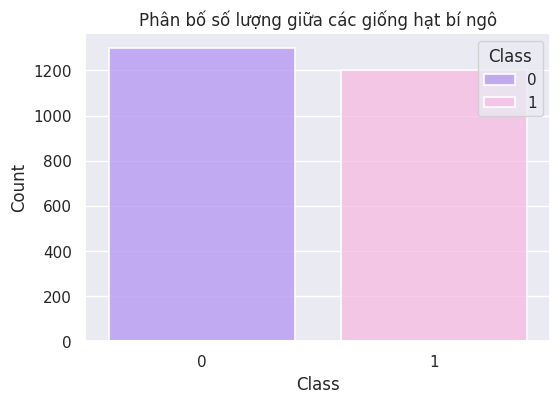

In [249]:
fig, axs = plt.subplots(figsize=(6, 4))

sns.set_theme(style="darkgrid")
sns.countplot(data=df, x=y, hue=y, linewidth=1.5, edgecolor="white",
              alpha=0.8, palette=["#B28DFF", "#FFB5E8"])

plt.title('Phân bố số lượng giữa các giống hạt bí ngô')
plt.xlabel('Class')
plt.ylabel('Count')

plt.show()

In [250]:
import plotly.graph_objects as go

# Đếm số lượng từng lớp
counts = y.value_counts()

labels = counts.index.tolist()
values = counts.values.tolist()

fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=values,
    hole=0.4,   # 👈 tạo donut
    marker=dict(colors=["#B28DFF", "#FFB5E8"]),  # pastel
    textinfo='percent+label'
)])

fig.update_layout(
    title_text="Tỷ lệ các giống hạt bí ngô",
    annotations=[dict(text='Class', x=0.5, y=0.5,
                      font_size=16, showarrow=False)]
)

fig.show()

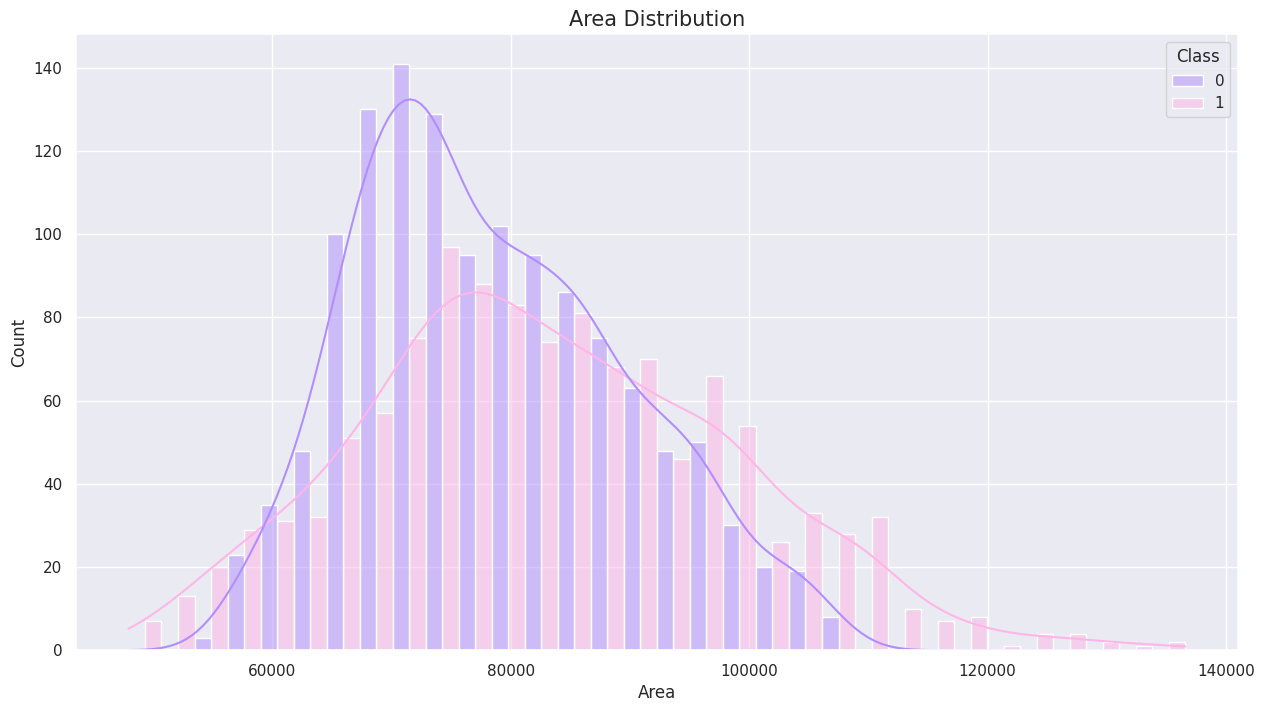

In [251]:
plt.figure(figsize=(15,8))
sns.histplot(data=df, x="Area", kde=True, hue="Class", multiple='dodge',
             palette=["#B28DFF", "#FFB5E8"])

plt.title("Area Distribution", fontsize=15)
plt.show()

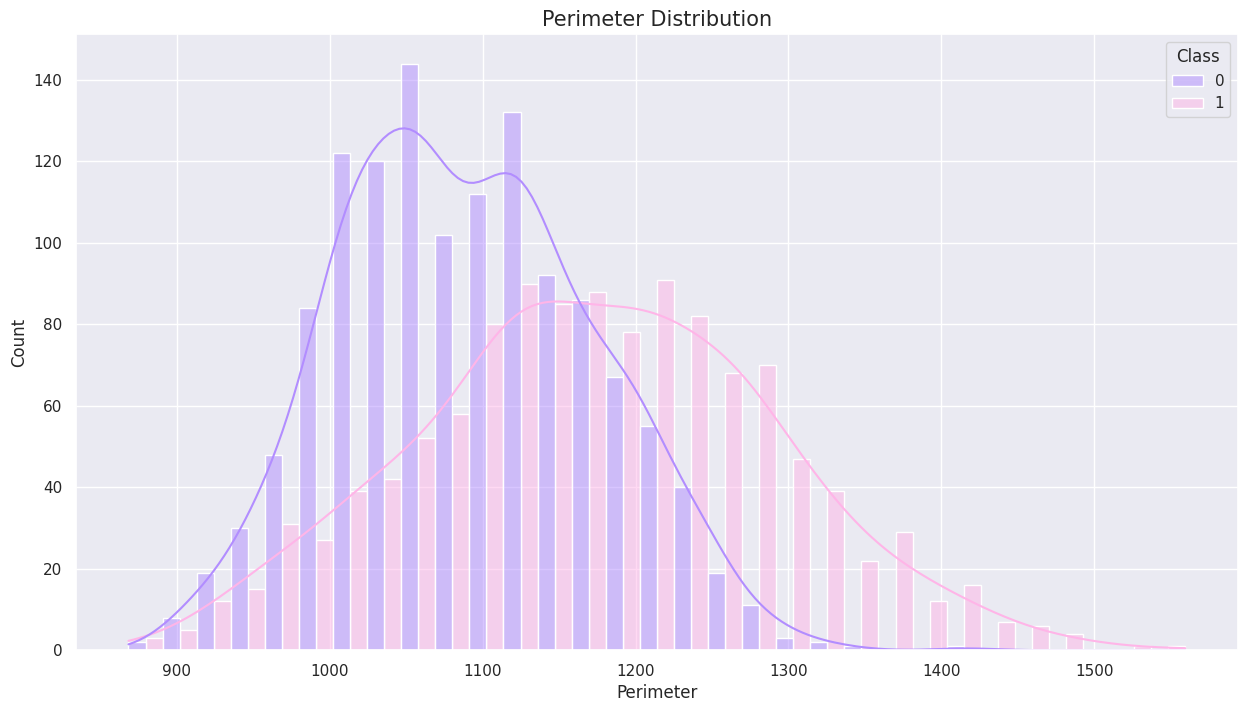

In [252]:
plt.figure(figsize=(15,8))
sns.histplot(data=df, x='Perimeter', kde=True, hue='Class', multiple='dodge',
             palette=["#B28DFF", "#FFB5E8"])
plt.title("Perimeter Distribution", fontsize=15)
plt.show()

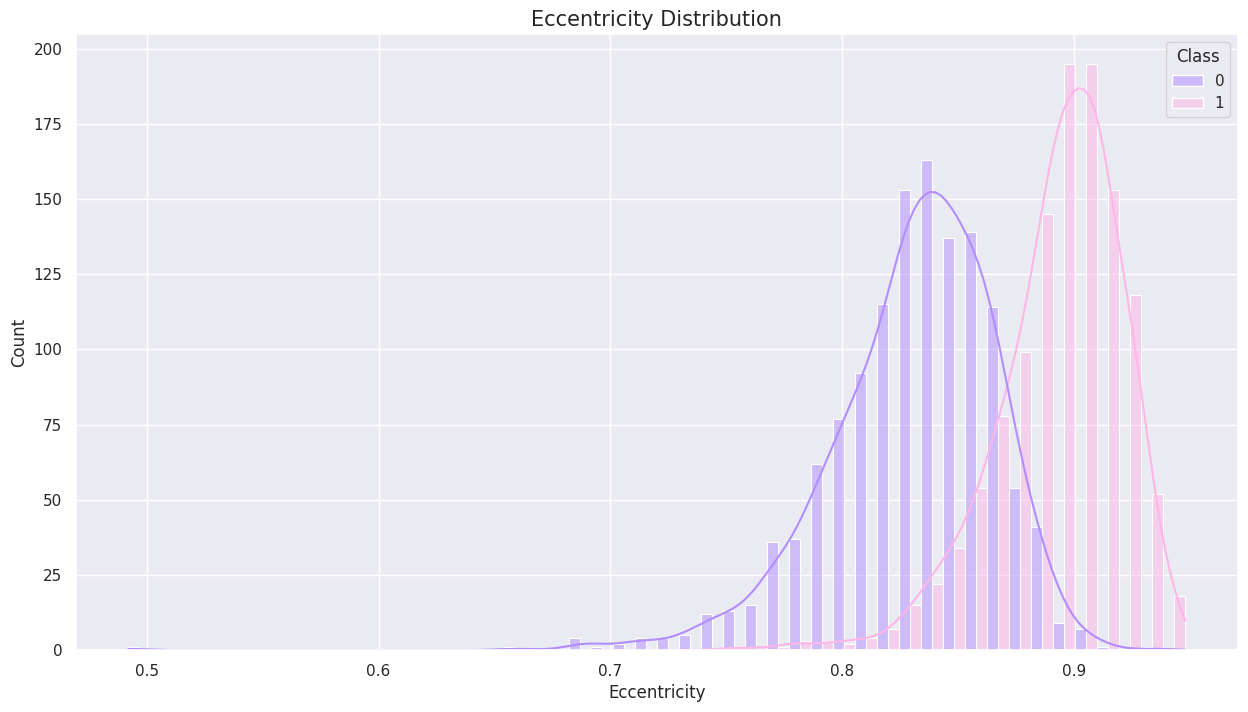

In [253]:
plt.figure(figsize=(15,8))
sns.histplot(data=df, x='Eccentricity', kde=True, hue='Class', multiple='dodge',
             palette=["#B28DFF", "#FFB5E8"])
plt.title("Eccentricity Distribution", fontsize=15)
plt.show()

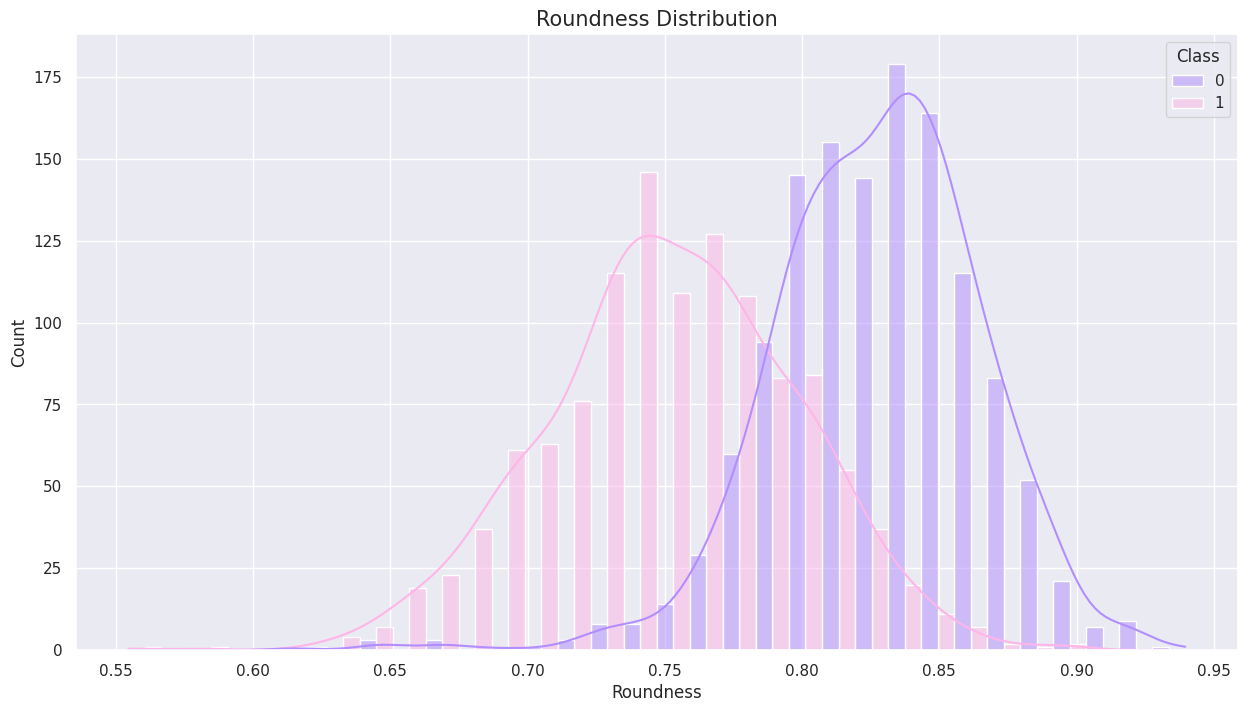

In [254]:
plt.figure(figsize=(15,8))
sns.histplot(data=df, x='Roundness', kde=True, hue='Class', multiple='dodge',
             palette=["#B28DFF", "#FFB5E8"])
plt.title("Roundness Distribution", fontsize=15)
plt.show()

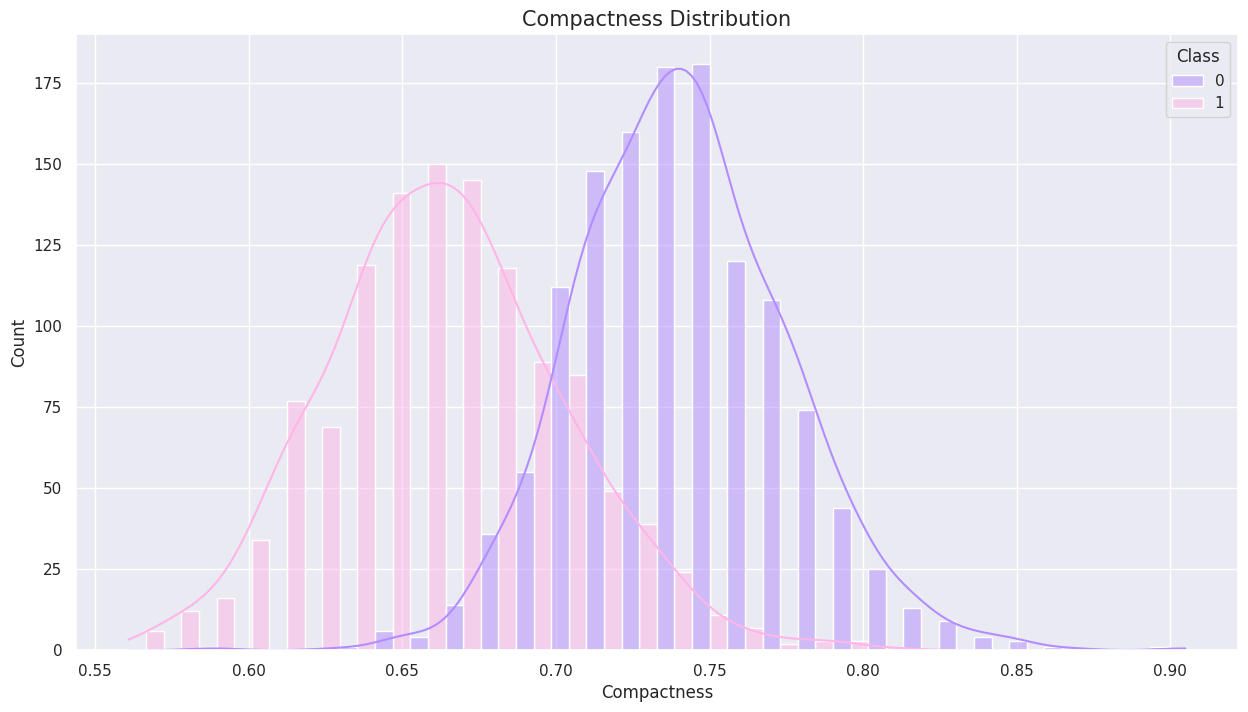

In [255]:
plt.figure(figsize=(15,8))
sns.histplot(data=df, x='Compactness', kde=True, hue='Class', multiple='dodge',
             palette=["#B28DFF", "#FFB5E8"])
plt.title("Compactness Distribution", fontsize=15)
plt.show()

/tmp/ipykernel_2345/1428616442.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2345/1428616442.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2345/1428616442.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2345/1428616442.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2345/1428616442.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated a

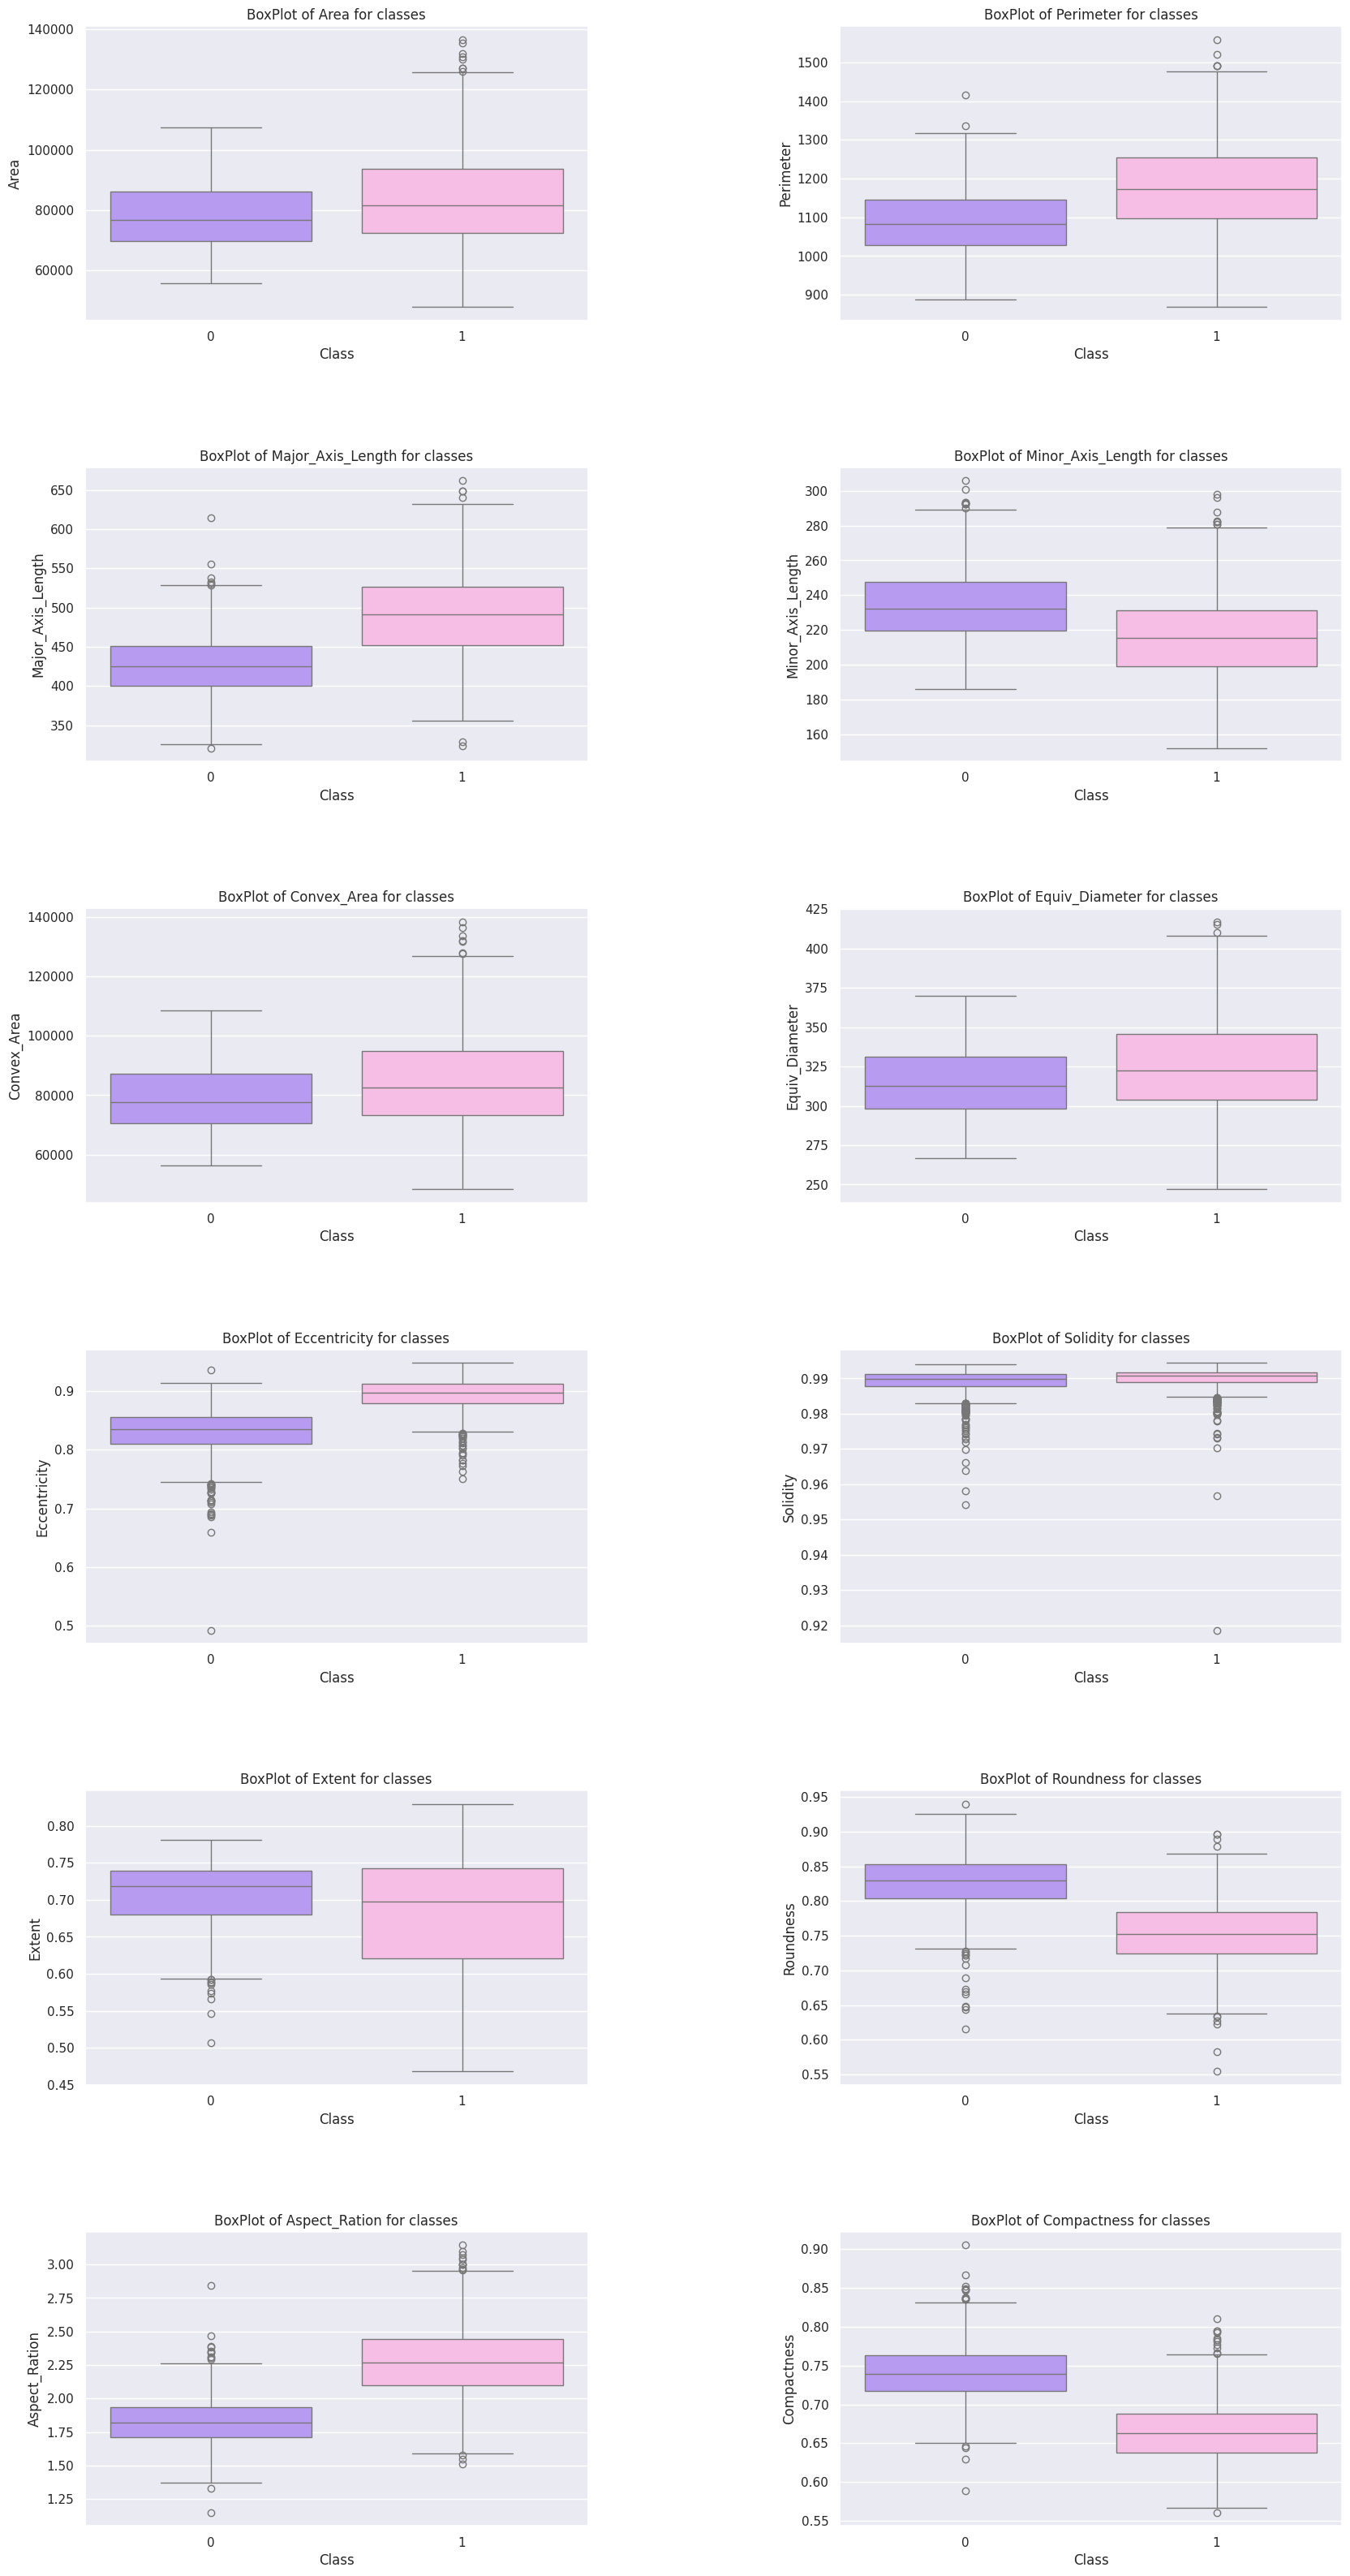

In [256]:
fig, axes = plt.subplots(nrows = 6, ncols = 2, figsize = (20, 40))
for nr, c in enumerate(df.columns):
    if c!= 'Class':
        sns.boxplot(data = df, x = 'Class', y = c,
                    ax = axes[nr // 2, nr % 2],
                    palette=["#B28DFF", "#FFB5E8"])
        axes[nr // 2, nr % 2].set_title('BoxPlot of ' + c + ' for classes')
plt.subplots_adjust(hspace = 0.5, wspace = 0.5)

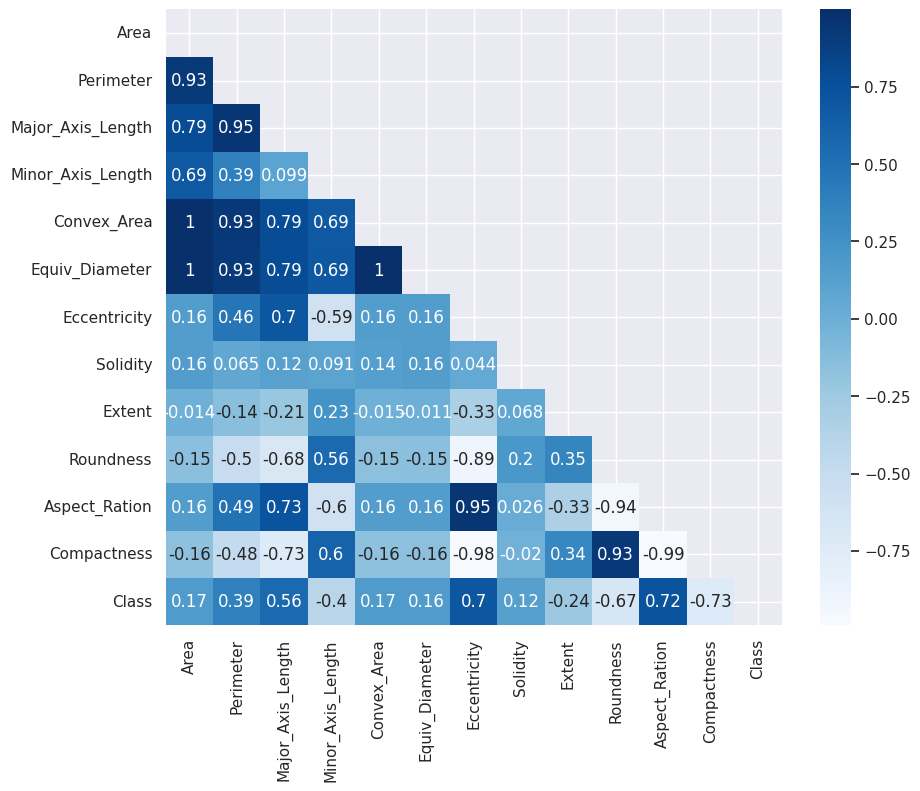

In [257]:
corr = df.corr()
# Tạo mask cho tam giác trên
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

# Vẽ heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, mask=mask, annot=True, cmap="Blues", square=True)
plt.show()

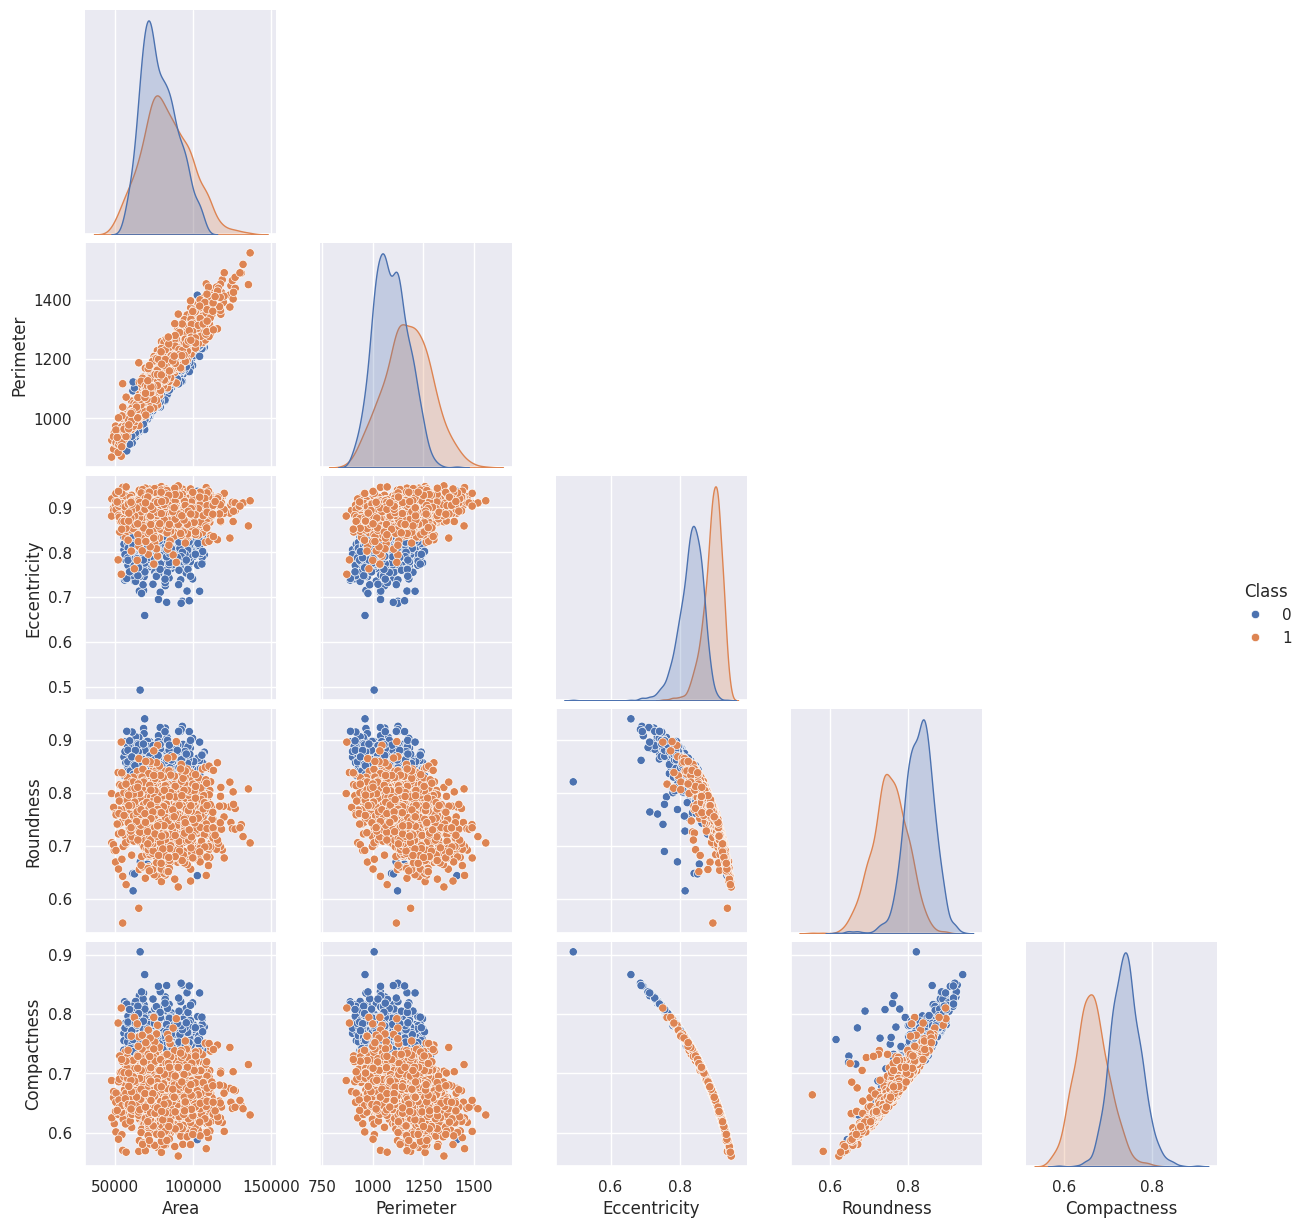

In [258]:
pairplot_features = [
    "Area",
    "Perimeter",
    "Eccentricity",
    "Roundness",
    "Compactness",
    "Class"
]

sns.pairplot(
    df[pairplot_features],
    hue="Class",
    corner=True
)

plt.show()

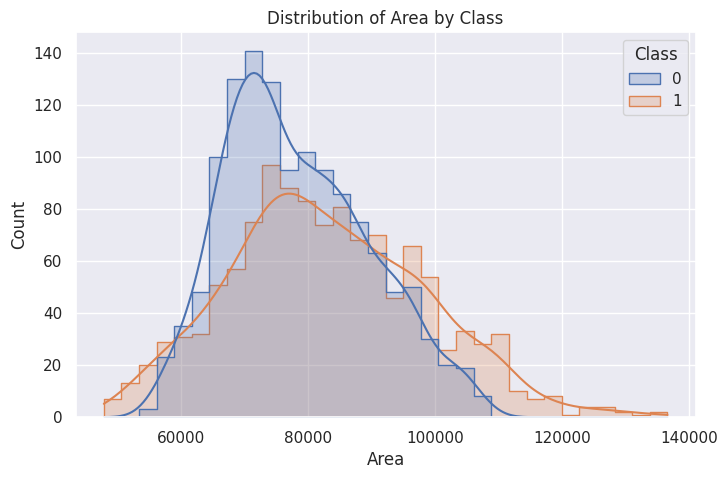

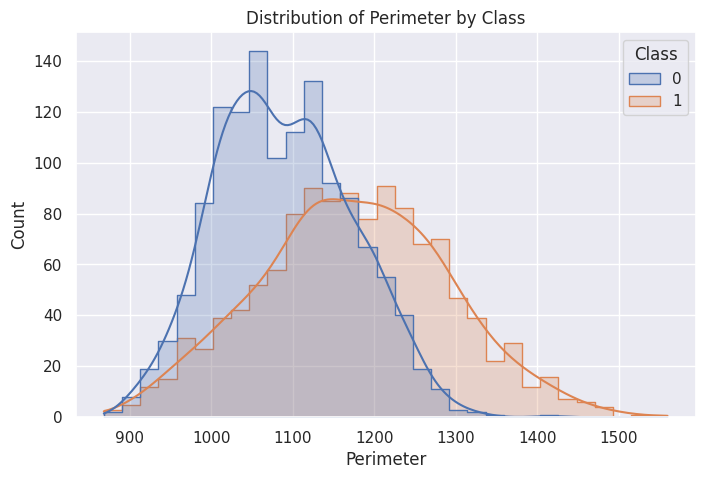

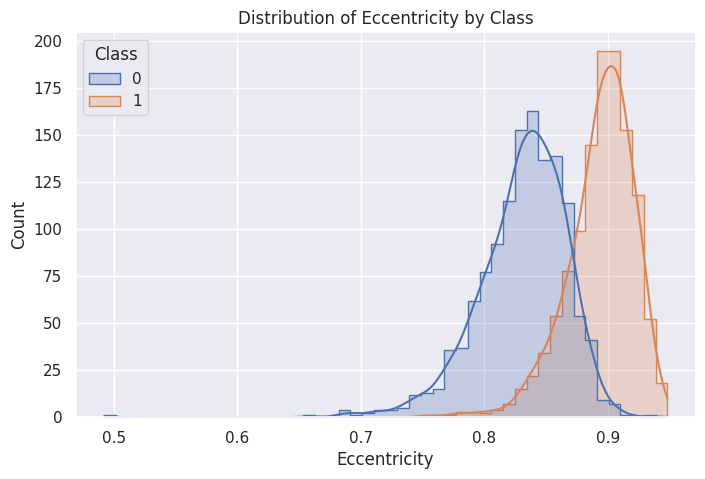

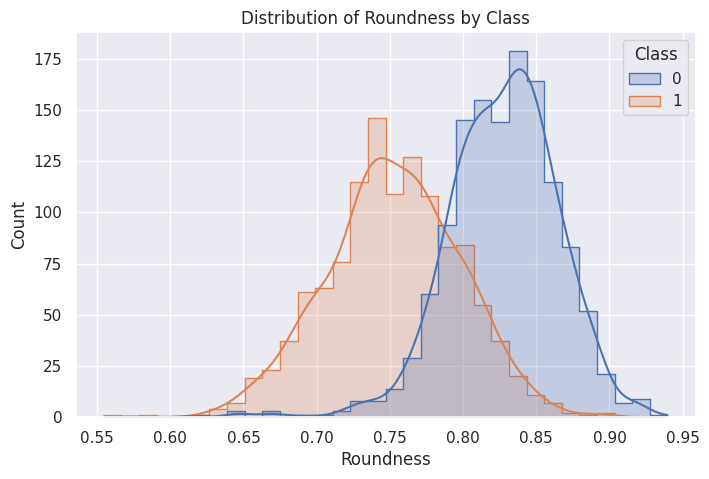

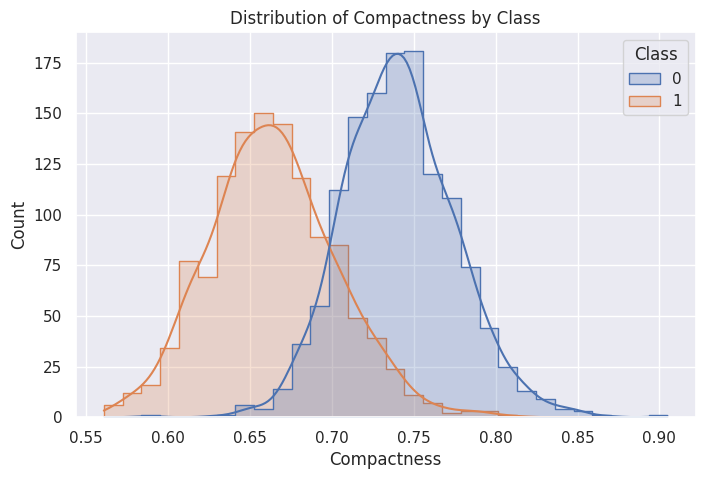

In [259]:
selected_features = [
    "Area",
    "Perimeter",
    "Eccentricity",
    "Roundness",
    "Compactness"
]

for feature in selected_features:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        kde=True,
        element="step"
    )

    plt.title(f"Distribution of {feature} by Class")
    plt.show()

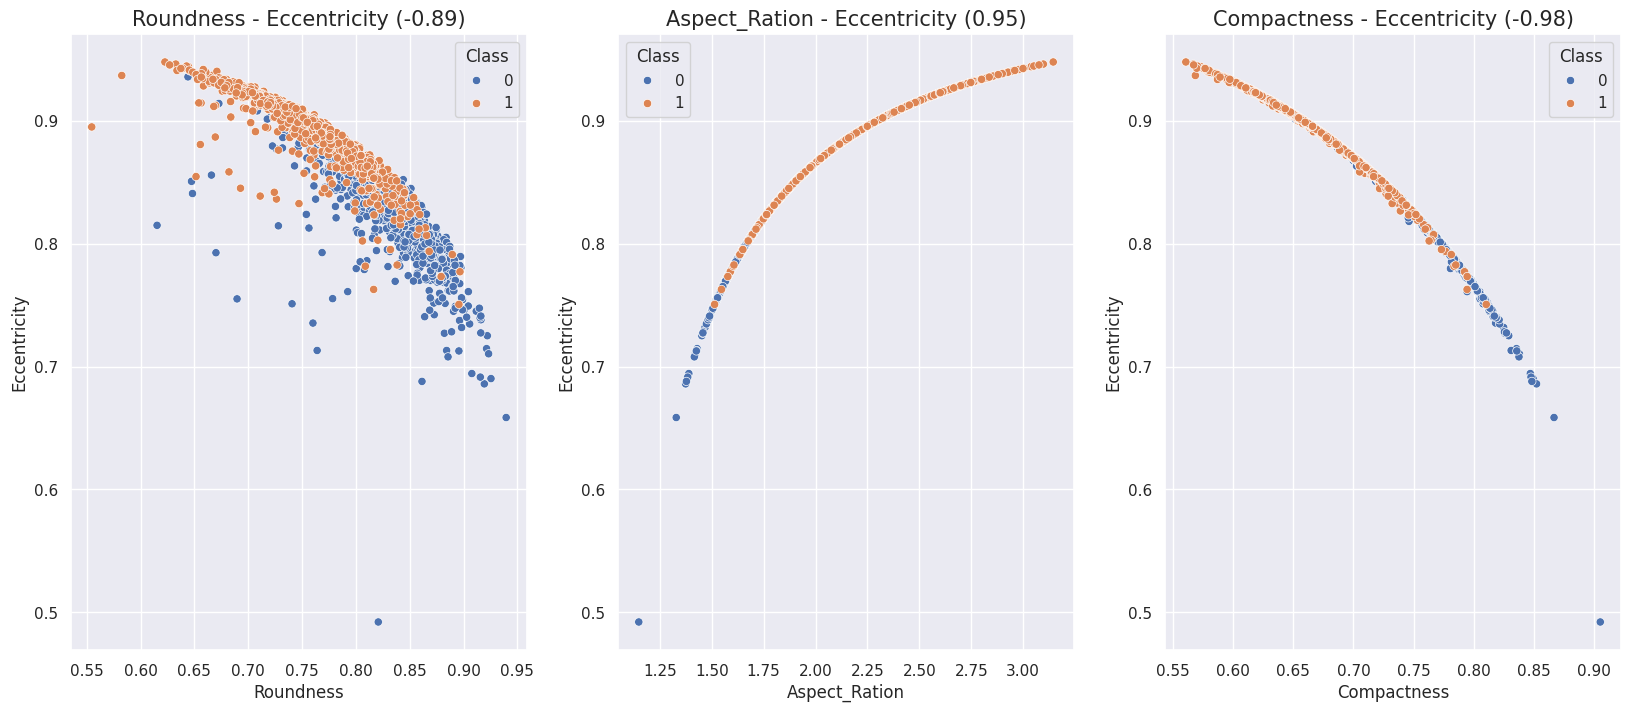

In [260]:
plt.figure(figsize=(20,8))

plt.subplot(1,3,1)
sns.scatterplot(data=df, x='Roundness', y='Eccentricity', hue='Class')
plt.title("Roundness - Eccentricity (-0.89)", fontsize=15)

plt.subplot(1,3,2)
sns.scatterplot(data=df, x='Aspect_Ration', y='Eccentricity', hue='Class')
plt.title("Aspect_Ration - Eccentricity (0.95)", fontsize=15)

plt.subplot(1,3,3)
sns.scatterplot(data=df, x='Compactness', y='Eccentricity', hue='Class')
plt.title("Compactness - Eccentricity (-0.98)", fontsize=15)

plt.show()

## 6. Model Training and Evaluation

# KNN

In [261]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(xtrain,ytrain)
ypred=knn.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87       379
           1       0.87      0.85      0.86       371

    accuracy                           0.86       750
   macro avg       0.86      0.86      0.86       750
weighted avg       0.86      0.86      0.86       750



In [262]:
accuracy_score(ytest,ypred)

0.8626666666666667

In [263]:
confusion_matrix(ytest,ypred)

array([[330,  49],
       [ 54, 317]])

In [264]:
accuracy=[]
for i in range(1,21):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(xtrain,ytrain)
    ypred=knn.predict(xtest)
    ac=accuracy_score(ytest,ypred)
    accuracy.append(ac)

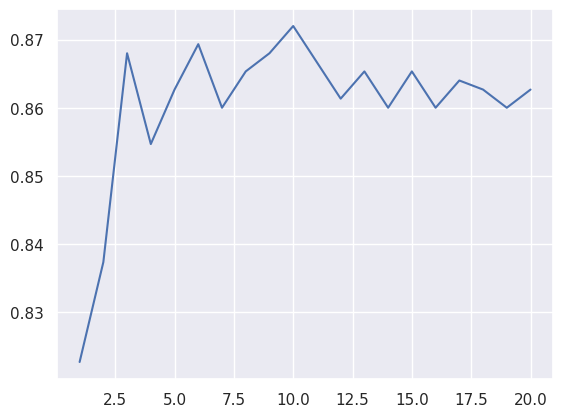

In [265]:
plt.plot(range(1,21),accuracy)
plt.grid(True)
plt.show()

In [266]:
knn=KNeighborsClassifier(n_neighbors=11)
knn.fit(xtrain,ytrain)
ypred=knn.predict(xtest)

In [267]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       379
           1       0.88      0.85      0.86       371

    accuracy                           0.87       750
   macro avg       0.87      0.87      0.87       750
weighted avg       0.87      0.87      0.87       750



In [268]:
accuracy_score(ytest,ypred)

0.8666666666666667

In [269]:
confusion_matrix(ytest,ypred)

array([[336,  43],
       [ 57, 314]])

Cross Validation Score

In [270]:
from sklearn.model_selection import cross_val_score
cvs=cross_val_score(knn,x,y,cv=5,scoring="accuracy")
print(f"CVS: {cvs}")
print(f"CVS Mean: {cvs.mean()}")
print(f"CVS Standard Deviation: {cvs.std()}")

CVS: [0.666 0.672 0.692 0.652 0.65 ]
CVS Mean: 0.6664000000000001
CVS Standard Deviation: 0.015252540771950072


Bagging

In [271]:
from sklearn.ensemble import BaggingClassifier
bg=BaggingClassifier(knn)
bg.fit(xtrain,ytrain)
ypred=bg.predict(xtest)

In [272]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87       379
           1       0.89      0.84      0.86       371

    accuracy                           0.87       750
   macro avg       0.87      0.87      0.87       750
weighted avg       0.87      0.87      0.87       750



In [273]:
accuracy_score(ytest,ypred)

0.8693333333333333

In [274]:
confusion_matrix(ytest,ypred)

array([[340,  39],
       [ 59, 312]])

# LOGISTIC REGRESSION

In [275]:
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression()
logreg.fit(xtrain,ytrain)
ypred=logreg.predict(xtest)

In [276]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       379
           1       0.88      0.85      0.86       371

    accuracy                           0.87       750
   macro avg       0.87      0.87      0.87       750
weighted avg       0.87      0.87      0.87       750



In [277]:
accuracy_score(ytest,ypred)

0.868

In [278]:
confusion_matrix(ytest,ypred)

array([[335,  44],
       [ 55, 316]])

Hyper-Parameter Tuning

In [279]:
params={
    "C":np.logspace(-3,3,7),
    "solver":["liblinear","lbfgs","newton-cg","sag","saga"],
    "penalty":["l1","l2","elasticnet"]
}

In [280]:
grid=GridSearchCV(logreg,params,verbose=3)
grid.fit(xtrain,ytrain)

Fitting 5 folds for each of 105 candidates, totalling 525 fits
[CV 1/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.529 total time=   0.0s
[CV 2/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.526 total time=   0.0s
[CV 3/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.526 total time=   0.0s
[CV 4/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.526 total time=   0.0s
[CV 5/5] END C=0.001, penalty=l1, solver=liblinear;, score=0.526 total time=   0.0s
[CV 1/5] END ...C=0.001, penalty=l1, solver=lbfgs;, score=nan total time=   0.0s
[CV 2/5] END ...C=0.001, penalty=l1, solver=lbfgs;, score=nan total time=   0.0s
[CV 3/5] END ...C=0.001, penalty=l1, solver=lbfgs;, score=nan total time=   0.0s
[CV 4/5] END ...C=0.001, penalty=l1, solver=lbfgs;, score=nan total time=   0.0s
[CV 5/5] END ...C=0.001, penalty=l1, solver=lbfgs;, score=nan total time=   0.0s
[CV 1/5] END C=0.001, penalty=l1, solver=newton-cg;, score=nan total time=   0.0s
[CV 2/5] END C=0.001, penalty=

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 5/5] END ...C=0.01, penalty=l1, solver=saga;, score=0.889 total time=   0.0s
[CV 1/5] END C=0.01, penalty=l2, solver=liblinear;, score=0.869 total time=   0.0s
[CV 2/5] END C=0.01, penalty=l2, solver=liblinear;, score=0.837 total time=   0.0s
[CV 3/5] END C=0.01, penalty=l2, solver=liblinear;, score=0.849 total time=   0.0s
[CV 4/5] END C=0.01, penalty=l2, solver=liblinear;, score=0.871 total time=   0.0s
[CV 5/5] END C=0.01, penalty=l2, solver=liblinear;, score=0.894 total time=   0.0s
[CV 1/5] END ..C=0.01, penalty=l2, solver=lbfgs;, score=0.874 total time=   0.0s
[CV 2/5] END ..C=0.01, penalty=l2, solver=lbfgs;, score=0.837 total time=   0.0s
[CV 3/5] END ..C=0.01, penalty=l2, solver=lbfgs;, score=0.849 total time=   0.0s
[CV 4/5] END ..C=0.01, penalty=l2, solver=lbfgs;, score=0.871 total time=   0.0s
[CV 5/5] END ..C=0.01, penalty=l2, solver=lbfgs;, score=0.900 total time=   0.0s
[CV 1/5] END C=0.01, penalty=l2, solver=newton-cg;, score=0.874 total time=   0.0s
[CV 2/5] END C=0

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 3/5] END ....C=0.1, penalty=l1, solver=saga;, score=0.863 total time=   0.0s
[CV 4/5] END ....C=0.1, penalty=l1, solver=saga;, score=0.880 total time=   0.0s
[CV 5/5] END ....C=0.1, penalty=l1, solver=saga;, score=0.891 total time=   0.0s
[CV 1/5] END C=0.1, penalty=l2, solver=liblinear;, score=0.874 total time=   0.0s
[CV 2/5] END C=0.1, penalty=l2, solver=liblinear;, score=0.829 total time=   0.0s
[CV 3/5] END C=0.1, penalty=l2, solver=liblinear;, score=0.860 total time=   0.0s
[CV 4/5] END C=0.1, penalty=l2, solver=liblinear;, score=0.874 total time=   0.0s
[CV 5/5] END C=0.1, penalty=l2, solver=liblinear;, score=0.883 total time=   0.0s
[CV 1/5] END ...C=0.1, penalty=l2, solver=lbfgs;, score=0.874 total time=   0.0s
[CV 2/5] END ...C=0.1, penalty=l2, solver=lbfgs;, score=0.834 total time=   0.0s
[CV 3/5] END ...C=0.1, penalty=l2, solver=lbfgs;, score=0.860 total time=   0.0s
[CV 4/5] END ...C=0.1, penalty=l2, solver=lbfgs;, score=0.877 total time=   0.0s
[CV 5/5] END ...C=0.1, 

...

[CV 2/5] END ..C=1000.0, penalty=l2, solver=sag;, score=0.843 total time=   0.1s
[CV 3/5] END ..C=1000.0, penalty=l2, solver=sag;, score=0.889 total time=   0.1s
[CV 4/5] END ..C=1000.0, penalty=l2, solver=sag;, score=0.877 total time=   0.1s
[CV 5/5] END ..C=1000.0, penalty=l2, solver=sag;, score=0.897 total time=   0.1s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



[CV 1/5] END .C=1000.0, penalty=l2, solver=saga;, score=0.886 total time=   0.1s
[CV 2/5] END .C=1000.0, penalty=l2, solver=saga;, score=0.840 total time=   0.1s
[CV 3/5] END .C=1000.0, penalty=l2, solver=saga;, score=0.871 total time=   0.1s
[CV 4/5] END .C=1000.0, penalty=l2, solver=saga;, score=0.883 total time=   0.1s
[CV 5/5] END .C=1000.0, penalty=l2, solver=saga;, score=0.903 total time=   0.1s
[CV 1/5] END C=1000.0, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 2/5] END C=1000.0, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 3/5] END C=1000.0, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 4/5] END C=1000.0, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 5/5] END C=1000.0, penalty=elasticnet, solver=liblinear;, score=nan total time=   0.0s
[CV 1/5] END C=1000.0, penalty=elasticnet, solver=lbfgs;, score=nan total time=   0.0s
[CV 2/5] END C=1000.0, penalty=elasticnet, solver=lbf

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning:


280 fits failed out of a total of 525.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_p

GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['liblinear', 'lbfgs', 'newton-cg', 'sag',
                                    'saga']},
             verbose=3)

In [281]:
grid.best_score_

np.float64(0.8811428571428571)

In [282]:
grid.best_params_

{'C': np.float64(100.0), 'penalty': 'l2', 'solver': 'liblinear'}

In [283]:
grid.best_estimator_

LogisticRegression(C=np.float64(100.0), solver='liblinear')

In [284]:
logreg=grid.best_estimator_
logreg.fit(xtrain,ytrain)
ypred=logreg.predict(xtest)

In [285]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       379
           1       0.89      0.86      0.88       371

    accuracy                           0.88       750
   macro avg       0.88      0.88      0.88       750
weighted avg       0.88      0.88      0.88       750



In [286]:
accuracy_score(ytest,ypred)

0.8786666666666667

In [287]:
confusion_matrix(ytest,ypred)

array([[339,  40],
       [ 51, 320]])

Cross Validation Score

In [288]:
from sklearn.model_selection import cross_val_score
cvs=cross_val_score(logreg,x,y,cv=5,scoring="accuracy")
print(f"CVS: {cvs}")
print(f"CVS Mean: {cvs.mean()}")
print(f"CVS Standard Deviation: {cvs.std()}")

CVS: [0.878 0.892 0.888 0.83  0.866]
CVS Mean: 0.8708
CVS Standard Deviation: 0.022292599668948455


Bagging

In [289]:
from sklearn.ensemble import BaggingClassifier
bg=BaggingClassifier(logreg)
bg.fit(xtrain,ytrain)
ypred=bg.predict(xtest)

In [290]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       379
           1       0.88      0.87      0.88       371

    accuracy                           0.88       750
   macro avg       0.88      0.88      0.88       750
weighted avg       0.88      0.88      0.88       750



In [291]:
accuracy_score(ytest,ypred)

0.8773333333333333

In [292]:
confusion_matrix(ytest,ypred)

array([[336,  43],
       [ 49, 322]])

# Random Forest

In [293]:
rf=RandomForestClassifier(n_estimators=102)
rf.fit(xtrain,ytrain)
ypred=rf.predict(xtest)

In [294]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88       379
           1       0.89      0.86      0.88       371

    accuracy                           0.88       750
   macro avg       0.88      0.88      0.88       750
weighted avg       0.88      0.88      0.88       750



In [295]:
accuracy_score(ytest,ypred)

0.8786666666666667

In [296]:
confusion_matrix(ytest,ypred)

array([[340,  39],
       [ 52, 319]])

Cross Validation Score

In [297]:
from sklearn.model_selection import cross_val_score
cvs=cross_val_score(rf,x,y,cv=5,scoring="accuracy")
print(f"CVS: {cvs}")
print(f"CVS Mean: {cvs.mean()}")
print(f"CVS Standard Deviation: {cvs.std()}")

CVS: [0.898 0.906 0.894 0.854 0.876]
CVS Mean: 0.8855999999999999
CVS Standard Deviation: 0.018607525359380827


# Naive Bayes

In [298]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(xtrain,ytrain)
ypred=nb.predict(xtest)

In [299]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86       379
           1       0.88      0.84      0.86       371

    accuracy                           0.86       750
   macro avg       0.86      0.86      0.86       750
weighted avg       0.86      0.86      0.86       750



In [300]:
accuracy_score(ytest,ypred)

0.86

In [301]:
confusion_matrix(ytest,ypred)

array([[335,  44],
       [ 61, 310]])

Cross Validation Score

In [302]:
from sklearn.model_selection import cross_val_score
cvs=cross_val_score(nb,x,y,cv=5,scoring="accuracy")
print(f"CVS: {cvs}")
print(f"CVS Mean: {cvs.mean()}")
print(f"CVS Standard Deviation: {cvs.std()}")

CVS: [0.816 0.834 0.804 0.772 0.772]
CVS Mean: 0.7996000000000001
CVS Standard Deviation: 0.024475293665245344


Bagging

In [303]:
from sklearn.ensemble import BaggingClassifier
bg=BaggingClassifier(nb)
bg.fit(xtrain,ytrain)
ypred=bg.predict(xtest)

In [304]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87       379
           1       0.88      0.84      0.86       371

    accuracy                           0.86       750
   macro avg       0.86      0.86      0.86       750
weighted avg       0.86      0.86      0.86       750



In [305]:
accuracy_score(ytest,ypred)

0.8613333333333333

In [306]:
confusion_matrix(ytest,ypred)

array([[335,  44],
       [ 60, 311]])

# Decision Tree

In [307]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(xtrain,ytrain)
ypred=dt.predict(xtest)

In [308]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.83       379
           1       0.82      0.86      0.84       371

    accuracy                           0.84       750
   macro avg       0.84      0.84      0.84       750
weighted avg       0.84      0.84      0.84       750



In [309]:
accuracy_score(ytest,ypred)

0.836

In [310]:
confusion_matrix(ytest,ypred)

array([[309,  70],
       [ 53, 318]])

Hyper-Parameter Tuning



Criterion-->"GINI"

In [311]:
s=0
for i in range(1,100):
    dt=DecisionTreeClassifier(criterion="gini",max_depth=i)
    dt.fit(xtrain,ytrain)
    ypred=dt.predict(xtest)
    ss=accuracy_score(ytest,ypred)
    if(s<ss):
        s=ss
        a=i
print(s,a)

0.8693333333333333 4


In [312]:
s=0
for i in range(1,100):
    dt=DecisionTreeClassifier(criterion="gini",min_samples_leaf=i)
    dt.fit(xtrain,ytrain)
    ypred=dt.predict(xtest)
    ss=accuracy_score(ytest,ypred)
    if(s<ss):
        s=ss
        a=i
print(s,a)

0.8786666666666667 15


Criterion-->"ENTROPY"

In [313]:
s=0
for i in range(1,100):
    dt=DecisionTreeClassifier(criterion="entropy",max_depth=i)
    dt.fit(xtrain,ytrain)
    ypred=dt.predict(xtest)
    ss=accuracy_score(ytest,ypred)
    if(s<ss):
        s=ss
        a=i
print(s,a)

0.8746666666666667 7


In [314]:
s=0
for i in range(1,100):
    dt=DecisionTreeClassifier(criterion="entropy",min_samples_leaf=i)
    dt.fit(xtrain,ytrain)
    ypred=dt.predict(xtest)
    ss=accuracy_score(ytest,ypred)
    if(s<ss):
        s=ss
        a=i
print(s,a)

0.88 34


In [315]:
dt=DecisionTreeClassifier(criterion="entropy",min_samples_leaf=24)
dt.fit(xtrain,ytrain)
ypred=dt.predict(xtest)

In [316]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       379
           1       0.89      0.85      0.87       371

    accuracy                           0.88       750
   macro avg       0.88      0.88      0.88       750
weighted avg       0.88      0.88      0.88       750



In [317]:
accuracy_score(ytest,ypred)

0.8773333333333333

In [318]:
confusion_matrix(ytest,ypred)

array([[341,  38],
       [ 54, 317]])

Tree

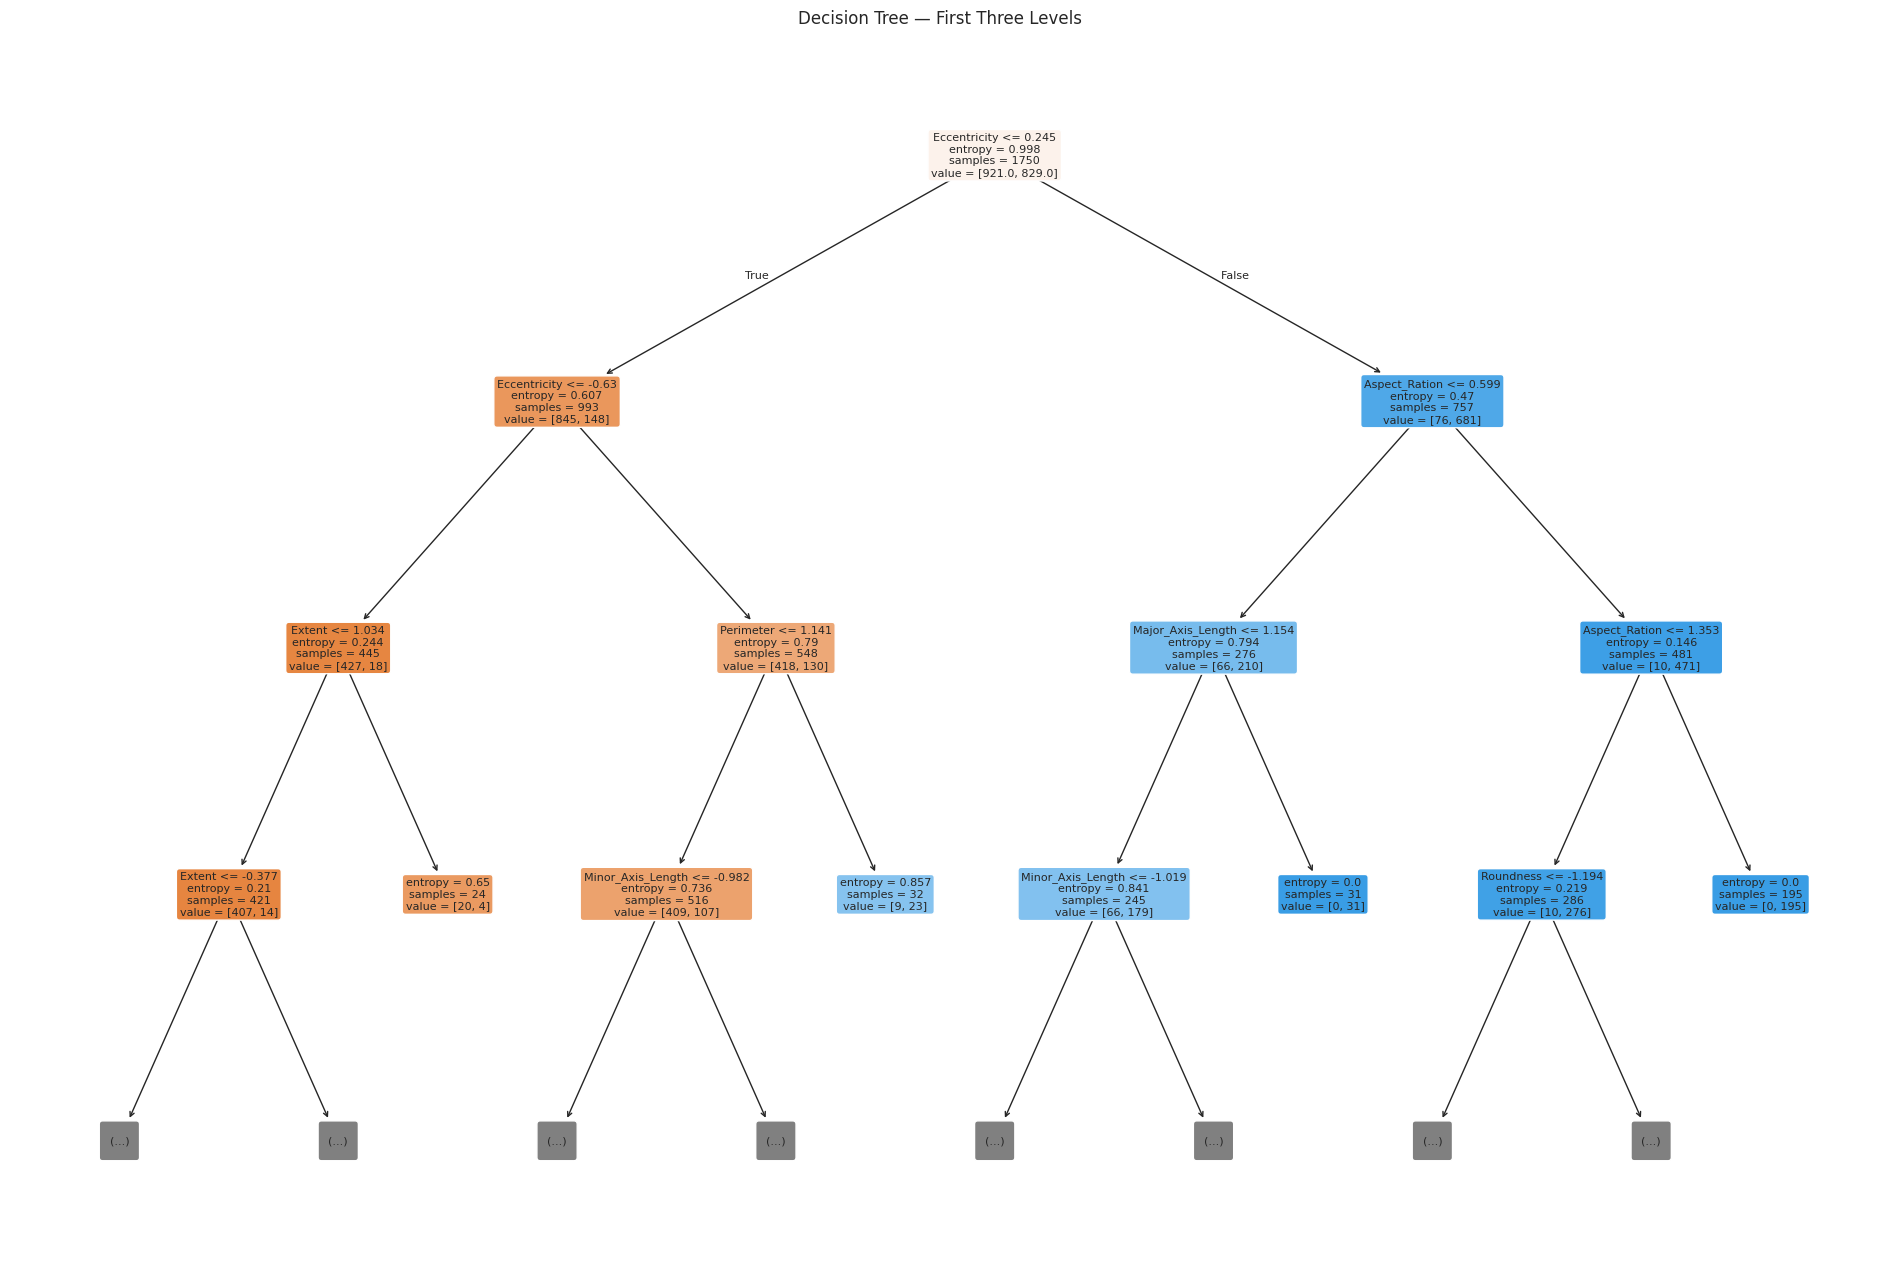

In [319]:
from sklearn import tree

fig, ax = plt.subplots(figsize=(24, 16))

tree.plot_tree(
    dt,
    feature_names=x.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    ax=ax
)

plt.title("Decision Tree — First Three Levels")
plt.show()

Cross Validation Score

In [320]:
from sklearn.model_selection import cross_val_score
cvs=cross_val_score(dt,x,y,cv=5,scoring="accuracy")
print(f"CVS: {cvs}")
print(f"CVS Mean: {cvs.mean()}")
print(f"CVS Standard Deviation: {cvs.std()}")

CVS: [0.888 0.896 0.896 0.842 0.854]
CVS Mean: 0.8752000000000001
CVS Standard Deviation: 0.0227191549138607


Bagging

In [321]:
from sklearn.ensemble import BaggingClassifier
bg=BaggingClassifier(dt)
bg.fit(xtrain,ytrain)
ypred=bg.predict(xtest)

In [322]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       379
           1       0.90      0.85      0.87       371

    accuracy                           0.88       750
   macro avg       0.88      0.88      0.88       750
weighted avg       0.88      0.88      0.88       750



In [323]:
accuracy_score(ytest,ypred)

0.8786666666666667

In [324]:
confusion_matrix(ytest,ypred)

array([[342,  37],
       [ 54, 317]])

# Support Vector Classifier

Kernel-->"rbf"

In [325]:
from sklearn.svm import SVC
svc=SVC(kernel="rbf")
svc.fit(xtrain,ytrain)
ypred=svc.predict(xtest)

In [326]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.86      0.91      0.89       379
           1       0.91      0.85      0.88       371

    accuracy                           0.88       750
   macro avg       0.88      0.88      0.88       750
weighted avg       0.88      0.88      0.88       750



In [327]:
accuracy_score(ytest,ypred)

0.8826666666666667

In [328]:
confusion_matrix(ytest,ypred)

array([[346,  33],
       [ 55, 316]])

Kernel-->"linear"

In [329]:
svc=SVC(kernel="linear")
svc.fit(xtrain,ytrain)
ypred=svc.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87       379
           1       0.88      0.85      0.87       371

    accuracy                           0.87       750
   macro avg       0.87      0.87      0.87       750
weighted avg       0.87      0.87      0.87       750



Kernel-->"poly"

In [330]:
svc=SVC(kernel="poly")
svc.fit(xtrain,ytrain)
ypred=svc.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.80      0.96      0.87       379
           1       0.95      0.75      0.84       371

    accuracy                           0.86       750
   macro avg       0.87      0.86      0.86       750
weighted avg       0.87      0.86      0.86       750



Kernel-->"sigmoid"

In [331]:
svc=SVC(kernel="sigmoid")
svc.fit(xtrain,ytrain)
ypred=svc.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80       379
           1       0.80      0.78      0.79       371

    accuracy                           0.80       750
   macro avg       0.80      0.80      0.80       750
weighted avg       0.80      0.80      0.80       750



# Boosting

Ada Boosting

In [332]:
from sklearn.ensemble import AdaBoostClassifier
abc = AdaBoostClassifier()
abc.fit(xtrain,ytrain)
ypred = abc.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       379
           1       0.88      0.83      0.85       371

    accuracy                           0.86       750
   macro avg       0.86      0.86      0.86       750
weighted avg       0.86      0.86      0.86       750



Gradient Boosting

In [333]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()
gb.fit(xtrain,ytrain)
ypred = gb.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.87      0.91      0.89       379
           1       0.90      0.87      0.88       371

    accuracy                           0.89       750
   macro avg       0.89      0.89      0.89       750
weighted avg       0.89      0.89      0.89       750



XG Boosting

In [334]:
from xgboost import XGBClassifier
xg = XGBClassifier()
xg.fit(xtrain, ytrain)
ypred = xg.predict(xtest)
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       379
           1       0.88      0.85      0.86       371

    accuracy                           0.87       750
   macro avg       0.87      0.87      0.87       750
weighted avg       0.87      0.87      0.87       750



# Voting Classifier

In [335]:
models=[]
models.append(("KNN",KNeighborsClassifier()))
models.append(("Logistic Regression",LogisticRegression()))
models.append(("Naive Bayes",GaussianNB()))
models.append(("Decision Tree",DecisionTreeClassifier()))
models.append(("Random Forest",RandomForestClassifier()))
models.append(("Support Vector Classifier",SVC()))
models.append(("Gradient Boosting Classifier",GradientBoostingClassifier()))

In [336]:
from sklearn.ensemble import VotingClassifier
vc=VotingClassifier(estimators=models)
vc.fit(xtrain,ytrain)
ypred=vc.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88       379
           1       0.89      0.86      0.88       371

    accuracy                           0.88       750
   macro avg       0.88      0.88      0.88       750
weighted avg       0.88      0.88      0.88       750



In [337]:
accuracy_score(ytest,ypred)

0.88

In [338]:
confusion_matrix(ytest,ypred)

array([[341,  38],
       [ 52, 319]])

## 7. Model Comparison

In [339]:
model_results = pd.DataFrame({
    "Model": [
        "KNN",
        "Logistic Regression",
        "Random Forest",
        "Naive Bayes",
        "Decision Tree",
        "SVM (RBF)",
        "Gradient Boosting",
        "Voting Classifier"
    ],
    "Accuracy": [
        0.8667,
        0.8787,
        0.8747,
        0.8600,
        0.8373,
        0.8827,
        0.8900,
        0.8773
    ]
})

model_results = model_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

model_results

,Model,Accuracy
0,Gradient Boosting,0.8900
1,SVM (RBF),0.8827
2,Logistic Regression,0.8787
3,Voting Classifier,0.8773
4,Random Forest,0.8747
5,KNN,0.8667
6,Naive Bayes,0.8600
7,Decision Tree,0.8373


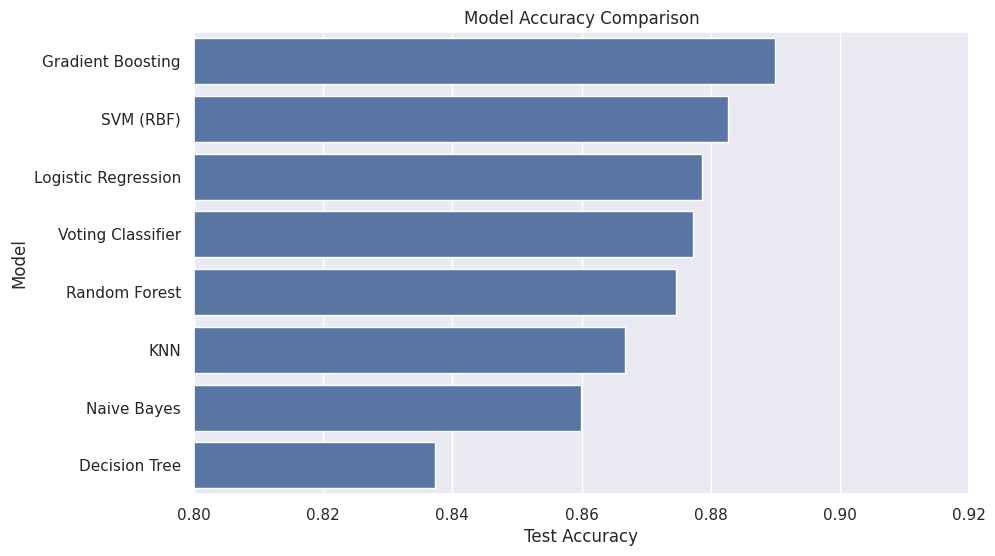

In [340]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_results,
    x="Accuracy",
    y="Model"
)

plt.title("Model Accuracy Comparison")
plt.xlim(0.80, 0.92)
plt.xlabel("Test Accuracy")
plt.ylabel("Model")
plt.show()

## 8. Conclusion



Multiple classification and ensemble learning models were developed and
evaluated for pumpkin seed variety classification.

Gradient Boosting achieved the best test performance with approximately
89% accuracy. Its precision, recall, and F1-score were relatively balanced
across the two seed classes.

The results suggest that ensemble learning methods are effective for
capturing the relationships between pumpkin seed geometric features and
seed varieties.